# Identifying Key Drivers of CTR and Conversion Rate in Google Ads Campaigns

This notebook walks through the full analysis behind the project. It answers
four questions:

1. Which factors (device, location, keyword characteristics) move CTR the most?
2. Which factors move conversion rate the most?
3. Can CTR and CVR be predicted to a useful degree from the available variables?
4. What should a growth team actually do with these findings?

The dataset is the [Google Ads Sales Dataset](https://www.kaggle.com/datasets/nayakganesh007/google-ads-sales-dataset)
from Kaggle. If you have not downloaded it, the repository ships a generator
that produces a synthetic file with the same schema, so the notebook runs
either way. The reusable logic lives in `src/`, this notebook calls it and
adds commentary.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_prep, eda, stats_analysis, modeling
from src.plotting import apply_style

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## Phase 1: data preparation

The raw file is messy on purpose: currency strings inside numeric columns,
two date formats, duplicate ad ids and a few rows where clicks exceed
impressions. `data_prep.clean` handles all of that, then `data_prep.engineer`
adds the derived metrics the analysis is about: CTR, CVR, CPC, ROAS, keyword
length and word count, a branded flag, and calendar features.

In [2]:
df = data_prep.run()
df.head()

Raw rows: 3535
Clean rows: 3500 (dropped 35)
Saved to data/processed/cleaned_google_ads.csv


,ad_id,ad_date,campaign_name,keyword,device,location,impressions,clicks,cost,leads,...,cpc,cpa,roas,revenue_per_click,keyword_length,keyword_word_count,is_branded,month,day_of_week,is_weekend
0,AD102745,2024-11-11,Search_Shoes_Delhi,Tennis Shoes,Mobile,Delhi,777.0000,34.0000,390.7500,4.0000,...,11.4926,390.7500,8.2715,95.0609,12,2,0,11,Monday,0
1,AD100259,2024-01-15,Search_Shoes_Hyderabad,White Sneakers Under 2000,Desktop,Hyderabad,760.0000,26.0000,341.2700,4.0000,...,13.1258,85.3175,45.9791,603.5115,25,4,0,1,Monday,0
2,AD100449,2024-12-09,Search_Shoes_Bangalore,Orthopedic Walking Shoes,Mobile,Bangalore,730.0000,42.0000,606.7400,6.0000,...,14.4462,151.6850,18.5542,268.0369,24,3,0,12,Monday,0
3,AD103066,2024-09-29,Search_Shoes_Bangalore,Stride Official Store,Mobile,Bangalore,"1,729.0000",138.0000,"1,571.7500",21.0000,...,11.3895,112.2679,27.6629,315.0663,21,3,1,9,Sunday,1
4,AD102607,2024-02-20,Search_Shoes_Mumbai,Tennis Shoes,Desktop,Mumbai,"2,950.0000",146.0000,"1,416.3800",19.0000,...,9.7012,118.0317,9.2882,90.1066,12,2,0,2,Tuesday,0


In [3]:
print(f"Rows: {len(df)}")
print(f"Date range: {df['ad_date'].min().date()} to {df['ad_date'].max().date()}")
print(f"Devices: {sorted(df['device'].dropna().unique())}")
print(f"Locations: {sorted(df['location'].dropna().unique())}")
print(f"Branded share: {df['is_branded'].mean():.1%}")

Rows: 3500
Date range: 2024-01-01 to 2024-12-30
Devices: ['Desktop', 'Mobile', 'Tablet']
Locations: ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Mumbai', 'Pune']
Branded share: 21.3%


## Phase 2: exploratory analysis

A quick look at the shape of the two target variables, then the splits that
matter for the research questions. Every figure is also saved under
`reports/figures/`.

In [4]:
eda.summary_table(df)

,count,mean,std,min,25%,50%,75%,max
impressions,"3,500.0000","1,323.9034","1,409.3198",48.0000,493.0000,879.5000,"1,656.2500","17,825.0000"
clicks,"3,500.0000",57.3509,67.9627,0.0000,19.0000,37.0000,70.0000,"1,364.0000"
cost,"3,430.0000",740.4203,891.4955,0.0000,242.7600,464.7550,914.1100,"12,186.5400"
conversions,"3,430.0000",4.1837,6.8627,0.0000,1.0000,2.0000,5.0000,131.0000
ctr,"3,500.0000",0.0434,0.0158,0.0000,0.0323,0.0415,0.0521,0.1182
cvr,"3,428.0000",0.0662,0.0574,0.0000,0.0253,0.0577,0.0960,0.5000
cpc,"3,428.0000",13.1853,3.4876,2.0600,10.8660,13.3298,15.5884,24.7784
roas,"3,428.0000",15.4023,18.1697,0.0000,3.9392,10.5846,20.1756,186.7198


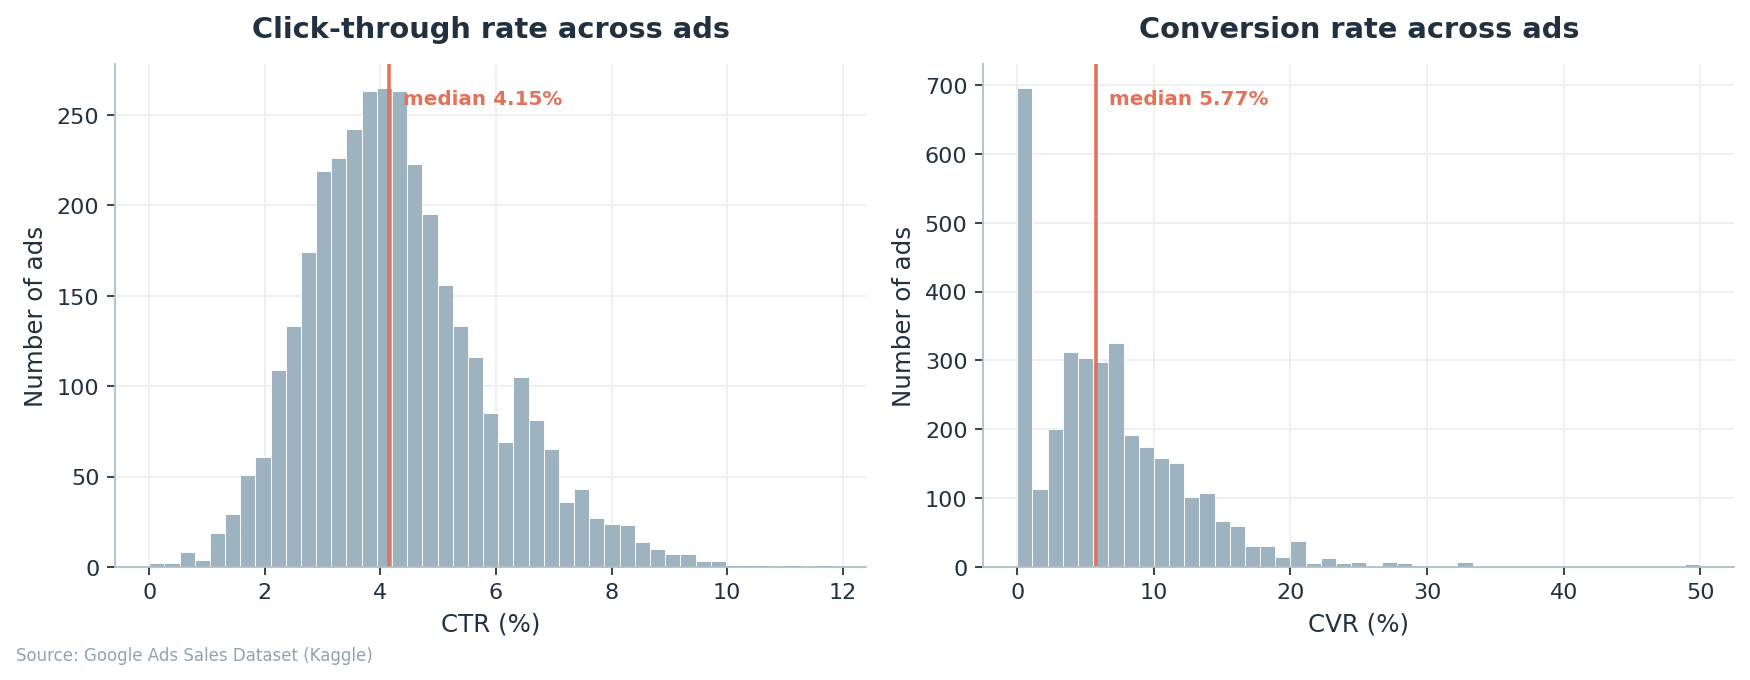

In [5]:
eda.FIG_DIR.mkdir(parents=True, exist_ok=True)
eda.fig_rate_distributions(df)
from IPython.display import Image, display
display(Image("reports/figures/01_rate_distributions.png"))

Both rates are right skewed, which is normal for ads data: most ads sit near
the account average and a small group performs far above it. The skew is one
reason the later hypothesis tests use rank based methods instead of plain
t tests.

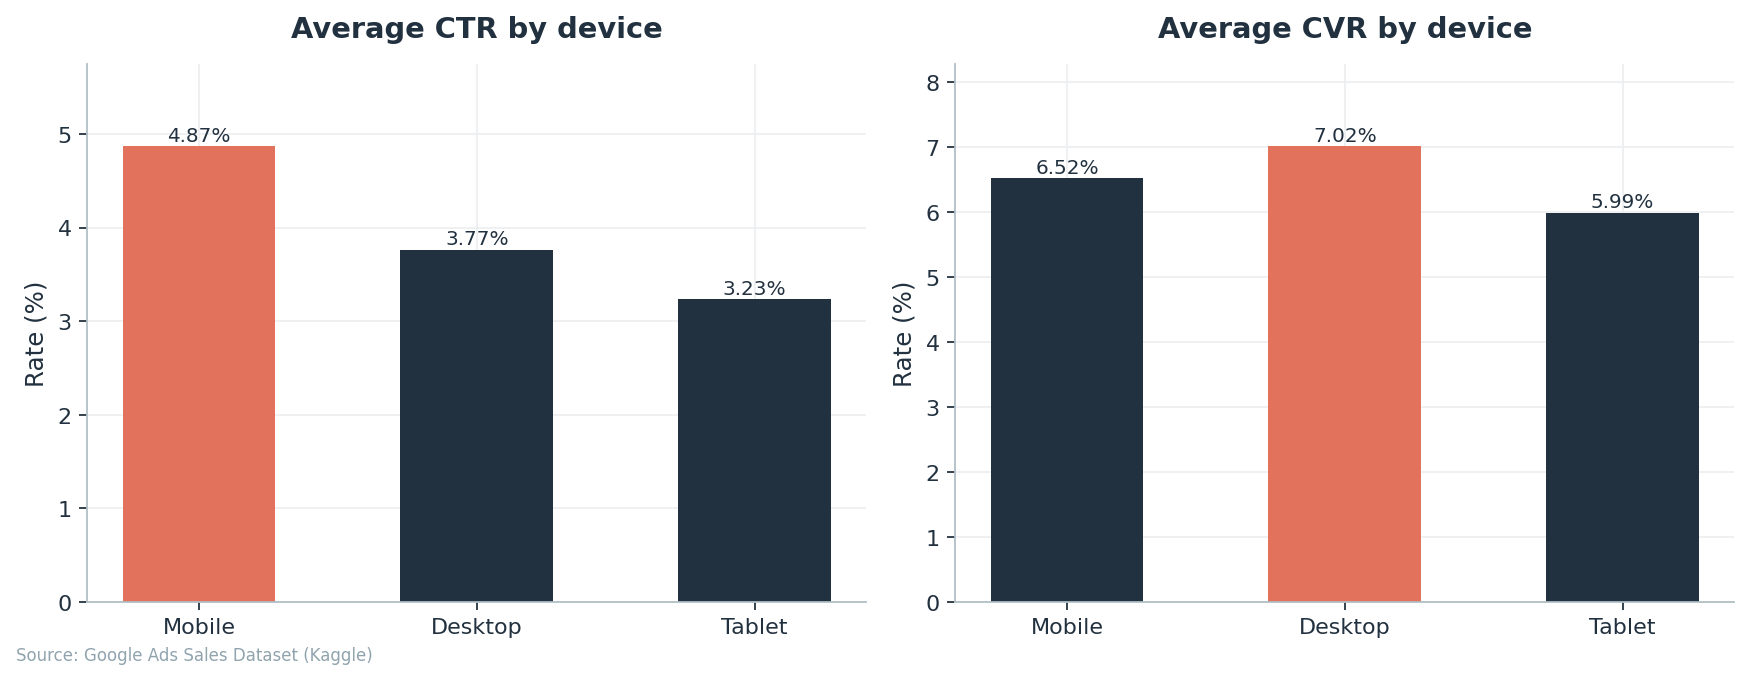

In [6]:
eda.fig_device_split(df)
display(Image("reports/figures/02_device_split.png"))

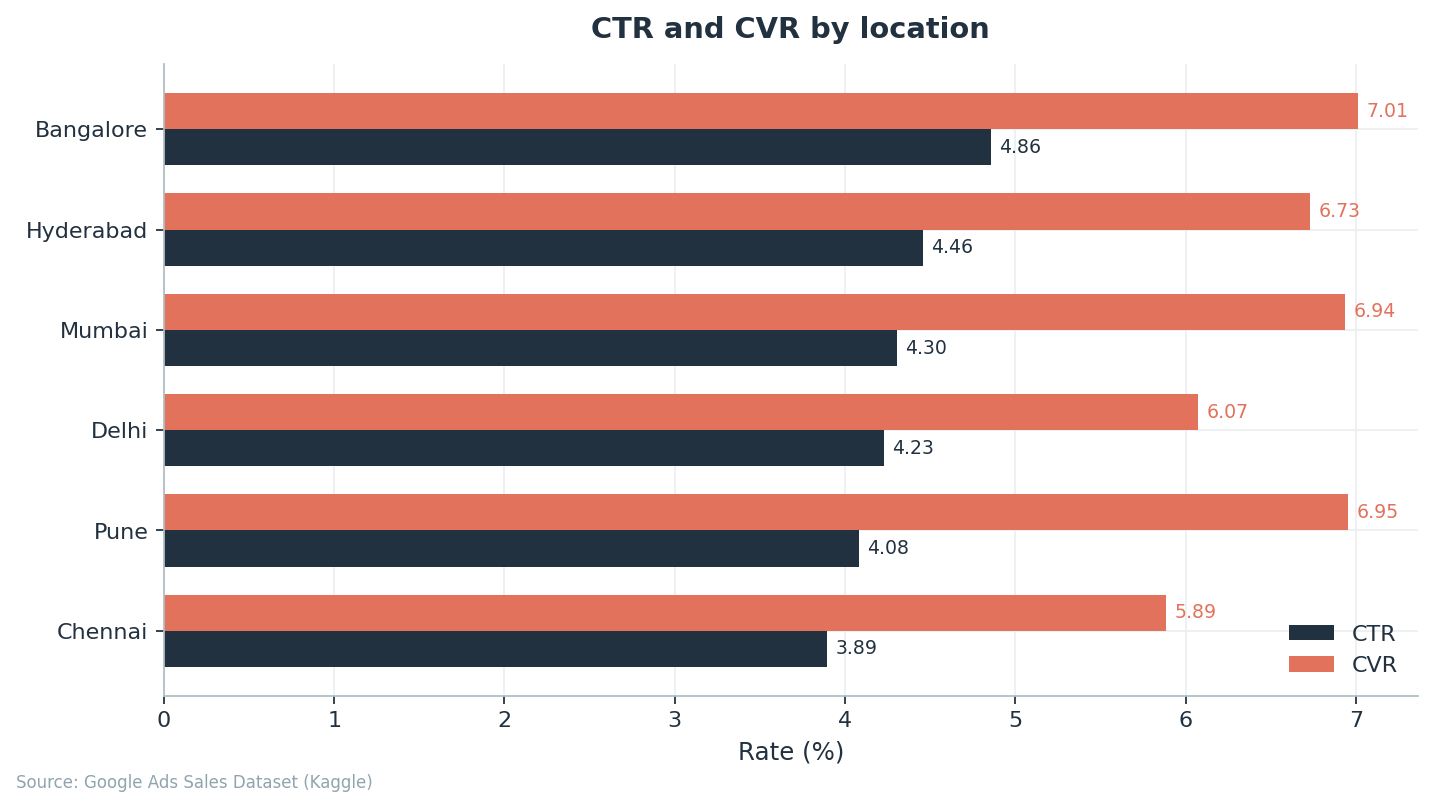

In [7]:
eda.fig_location_split(df)
display(Image("reports/figures/03_location_split.png"))

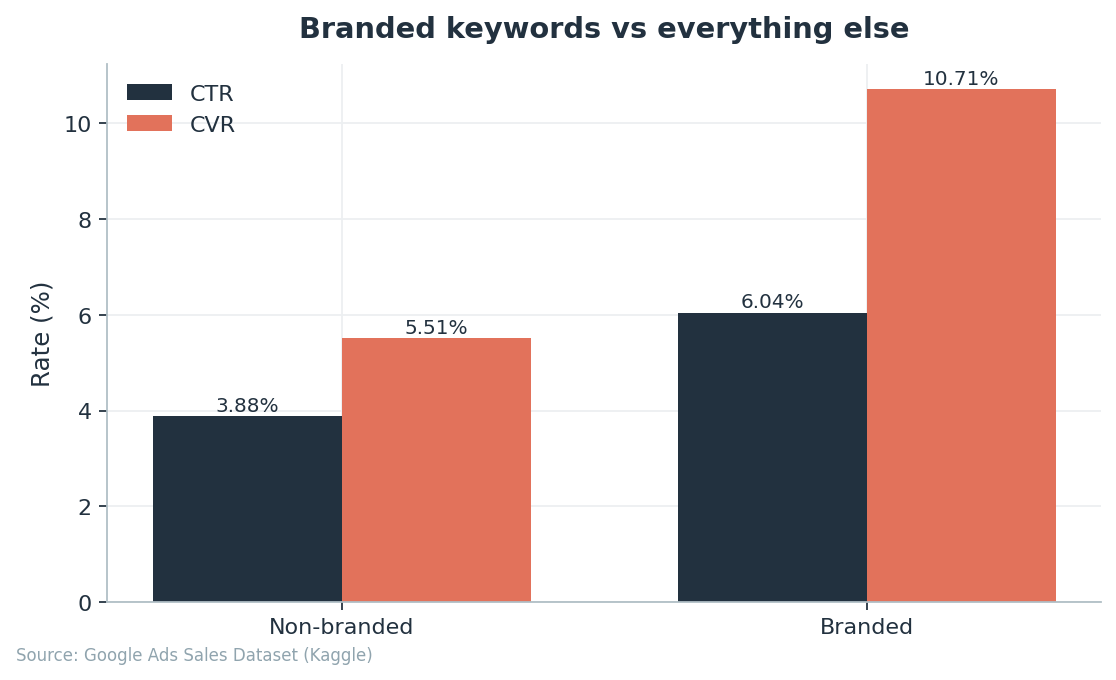

In [8]:
eda.fig_branded_split(df)
display(Image("reports/figures/04_branded_split.png"))

The branded split is the loudest signal so far. Branded queries both click
and convert at a much higher rate, which matches what practitioners see in
real accounts: people searching for a brand are already late in the funnel.
The important consequence is that any analysis that ignores the branded flag
risks attributing this lift to whatever variable happens to correlate with it.

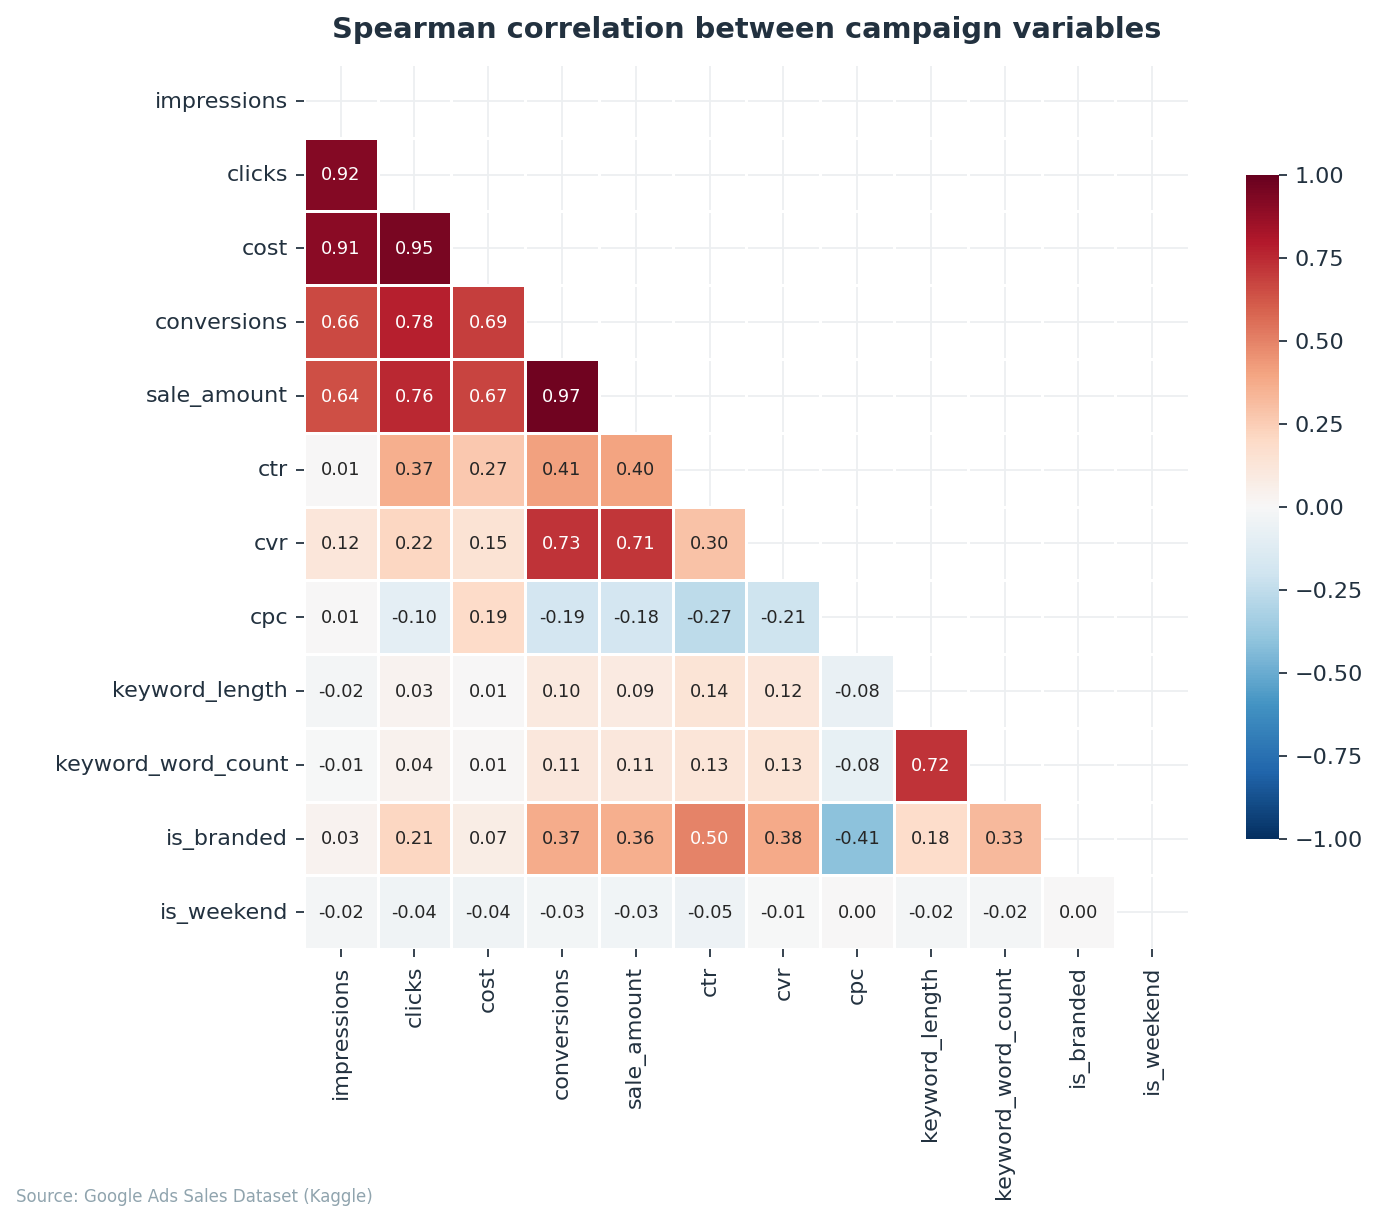

In [9]:
eda.fig_correlation(df)
display(Image("reports/figures/05_correlation_heatmap.png"))

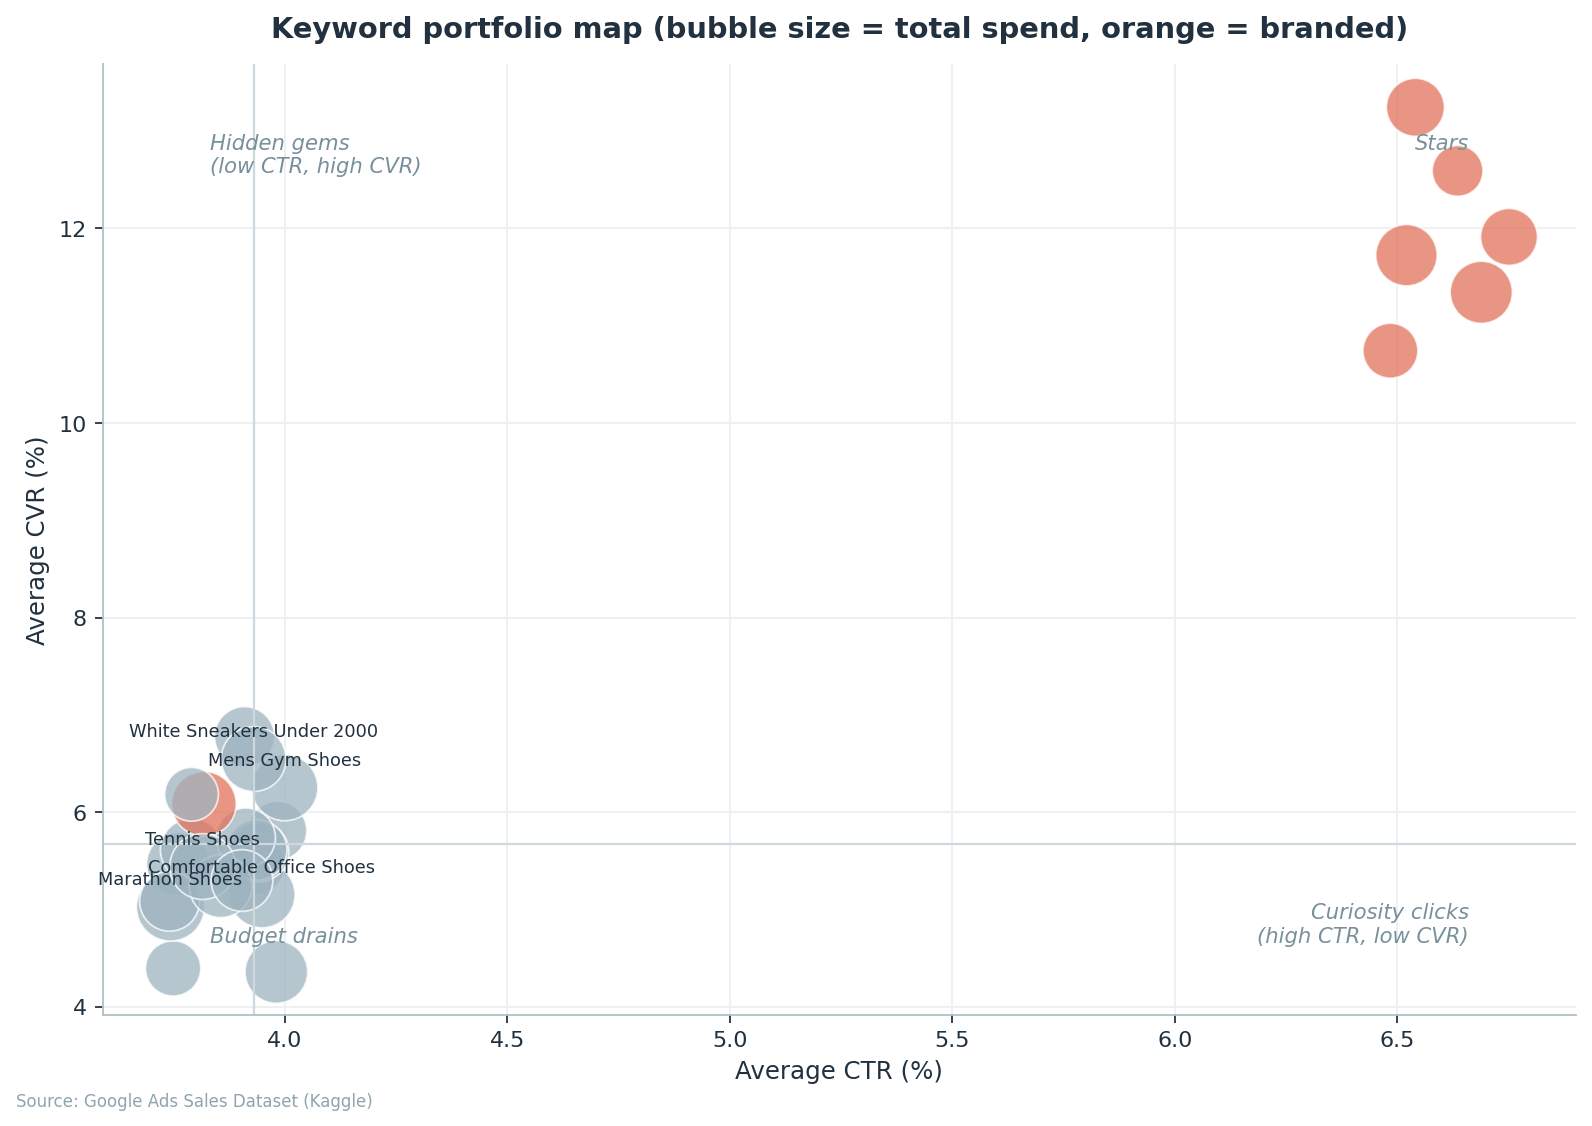

In [10]:
eda.fig_keyword_quadrants(df)
display(Image("reports/figures/07_keyword_quadrants.png"))

The portfolio map is the chart I would put in front of a client. Each bubble
is one keyword, sized by total spend, split into four quadrants at the median
CTR and median CVR:

* **Stars** earn their budget on both metrics.
* **Hidden gems** convert well but rarely get clicked, usually an ad copy
  or position problem, not a targeting problem.
* **Curiosity clicks** attract clicks that go nowhere, often a sign the ad
  promises something the landing page does not deliver.
* **Budget drains** underperform on both and are the first place to cut.

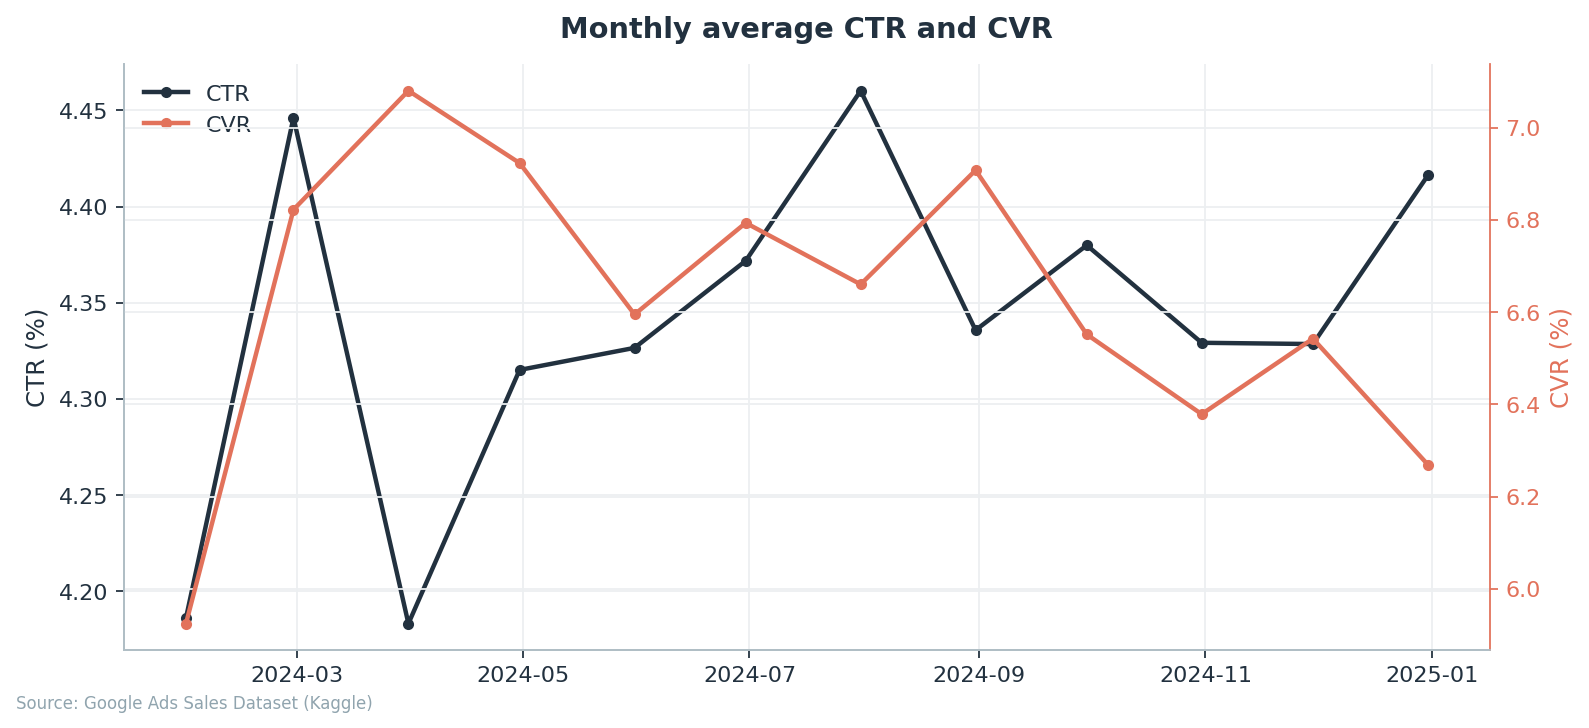

In [11]:
eda.fig_monthly_trend(df)
display(Image("reports/figures/08_monthly_trend.png"))

## Phase 3: statistical driver analysis

Two weighted least squares models, one per target. Each observation is
weighted by its denominator (impressions for CTR, clicks for CVR), because a
rate computed from 40 impressions is far noisier than one computed from
4,000. Standard errors are HC3 robust. The coefficients are in percentage
points, so they read directly as "switching from desktop to mobile is worth
about X points of CTR, all else equal".

In [12]:
ctr_model, cvr_model = stats_analysis.fit_models(df)
print(f"CTR model R2: {ctr_model.rsquared:.3f}")
print(f"CVR model R2: {cvr_model.rsquared:.3f}")

CTR model R2: 0.599
CVR model R2: 0.331


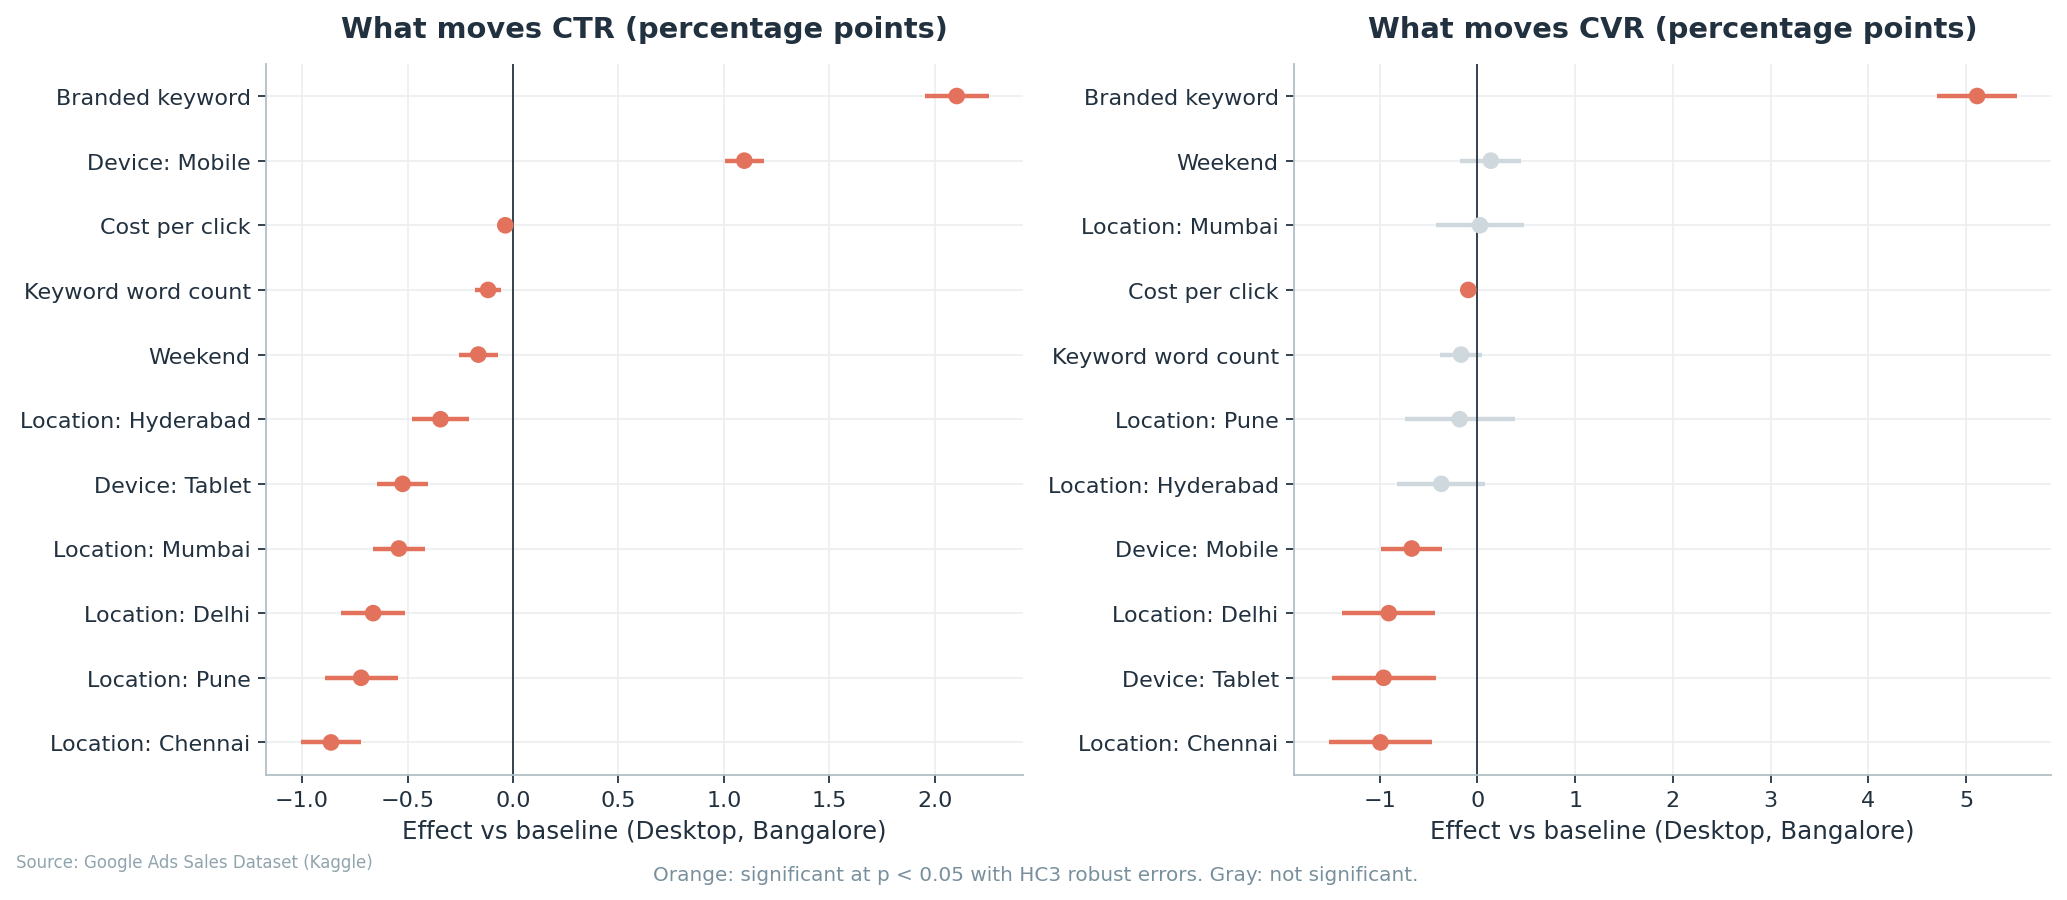

In [13]:
stats_analysis.fig_coefficients(ctr_model, cvr_model)
display(Image("reports/figures/09_regression_coefficients.png"))

In [14]:
ctr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                ctr_pct   R-squared:                       0.599
Model:                            WLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     213.9
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:29:07   Log-Likelihood:                -5366.0
No. Observations:                3428   AIC:                         1.076e+04
Df Residuals:                    3416   BIC:                         1.083e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     4.6806      0.162     28.835      0.000       4.362       4.999
C(device, Treatment('Desktop'))[T.Mobile]     1.0970      0.047     23.144      0.000       1.004       1.190
C(device, Treatment('Desktop'))[T.Tablet]    -0.5235      0.061     -8.553      0.000      -0.644      -0.404
C(location)[T.Chennai]                       -0.8631      0.073    -11.747      0.000      -1.007      -0.719
C(location)[T.Delhi]                         -0.6633      0.077     -8.598      0.000      -0.814      -0.512
C(location)[T.Hyderabad]                     -0.3438      0.068     -5.029      0.000      -0.478      -0.210
C(location)[T.Mumbai]                        -0.5411      0.063     -8.530      0.000      -0.665      -0.417
C(location)[T.Pune]                          -0.7202      0.088     -8.174      0.000      -0.893      -0.548
is_branded                                    2.1043      0.078     27.121      0.000       1.952       2.256
keyword_word_count                           -0.1182      0.032     -3.711      0.000      -0.181      -0.056
is_weekend                                   -0.1644      0.047     -3.470      0.001      -0.257      -0.072
cpc                                          -0.0366      0.007     -5.054      0.000      -0.051      -0.022
==============================================================================
Omnibus:                      344.071   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1126.804
Skew:                          -0.499   Prob(JB):                    2.08e-245
Kurtosis:                       5.626   Cond. No.                         104.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [15]:
cvr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                cvr_pct   R-squared:                       0.331
Model:                            WLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     101.9
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          1.60e-200
Time:                        06:29:07   Log-Likelihood:                -9899.4
No. Observations:                3358   AIC:                         1.982e+04
Df Residuals:                    3346   BIC:                         1.990e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     8.2070      0.501     16.396      0.000       7.226       9.188
C(device, Treatment('Desktop'))[T.Mobile]    -0.6717      0.158     -4.242      0.000      -0.982      -0.361
C(device, Treatment('Desktop'))[T.Tablet]    -0.9599      0.272     -3.530      0.000      -1.493      -0.427
C(location)[T.Chennai]                       -0.9923      0.271     -3.667      0.000      -1.523      -0.462
C(location)[T.Delhi]                         -0.9073      0.242     -3.753      0.000      -1.381      -0.433
C(location)[T.Hyderabad]                     -0.3695      0.229     -1.611      0.107      -0.819       0.080
C(location)[T.Mumbai]                         0.0263      0.231      0.114      0.909      -0.426       0.478
C(location)[T.Pune]                          -0.1819      0.288     -0.632      0.528      -0.746       0.382
is_branded                                    5.1133      0.207     24.684      0.000       4.707       5.519
keyword_word_count                           -0.1678      0.109     -1.539      0.124      -0.381       0.046
is_weekend                                    0.1375      0.160      0.861      0.389      -0.176       0.451
cpc                                          -0.0933      0.024     -3.960      0.000      -0.139      -0.047
==============================================================================
Omnibus:                      187.782   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              248.692
Skew:                           0.525   Prob(JB):                     9.93e-55
Kurtosis:                       3.821   Cond. No.                         100.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

### Hypothesis tests

Three direct comparisons, run with the Mann-Whitney U test because the rate
distributions are skewed:

In [16]:
tests = stats_analysis.hypothesis_tests(df)
tests

,test,statistic,p_value,group_a_mean,group_b_mean
0,Mobile CTR > Desktop CTR (Mann-Whitney U),"1,611,939.5000",0.0000,0.0487,0.0377
1,Branded CVR > Non-branded CVR (Mann-Whitney U),"1,512,842.5000",0.0000,0.1071,0.0551
2,Weekend CTR differs from weekday CTR (Mann-Whi...,"1,186,758.5000",0.0027,0.0421,0.0439


## Phase 4: predictive modeling

Three regressors per target: ridge as the linear baseline, a random forest,
and histogram gradient boosting. The split is 75/25 and the metrics below are
on the held out test set. Importance is measured by permutation on the test
set, which avoids the bias tree impurity importances have toward
high cardinality features.

In [17]:
scores, importances = modeling.run(df)
scores

CTR: best model is Gradient Boosting


CVR: best model is Ridge


target             model     r2   rmse    mae
   CTR             Ridge 0.4513 1.0868 0.8108
   CTR     Random Forest 0.4850 1.0529 0.8015
   CTR Gradient Boosting 0.4972 1.0404 0.7929
   CVR             Ridge 0.1343 5.4176 3.9598
   CVR     Random Forest 0.1013 5.5198 4.0459
   CVR Gradient Boosting 0.0638 5.6337 4.1336
Outputs written to reports/tables/ and reports/figures/


,target,model,r2,rmse,mae
0,CTR,Ridge,0.4513,1.0868,0.8108
1,CTR,Random Forest,0.4850,1.0529,0.8015
2,CTR,Gradient Boosting,0.4972,1.0404,0.7929
3,CVR,Ridge,0.1343,5.4176,3.9598
4,CVR,Random Forest,0.1013,5.5198,4.0459
5,CVR,Gradient Boosting,0.0638,5.6337,4.1336


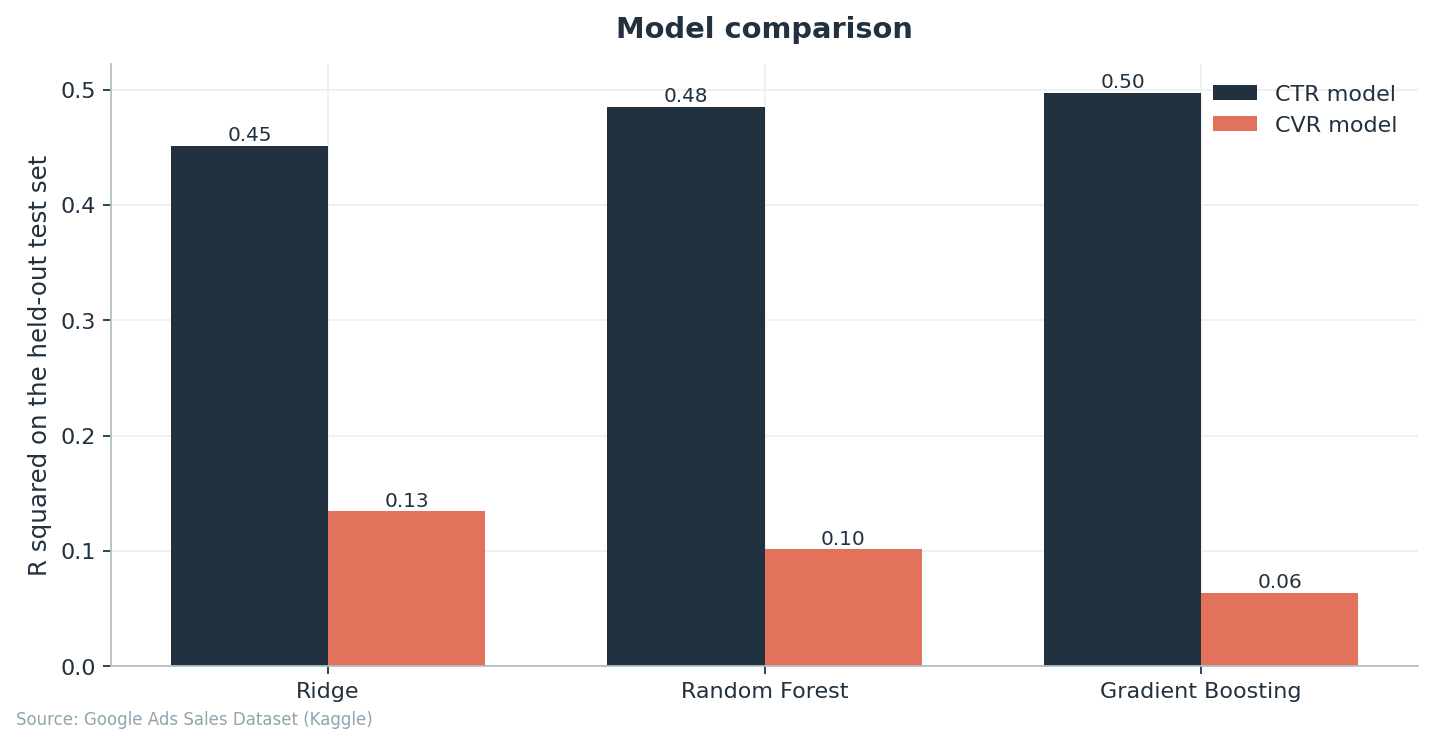

In [18]:
display(Image("reports/figures/10_model_comparison.png"))

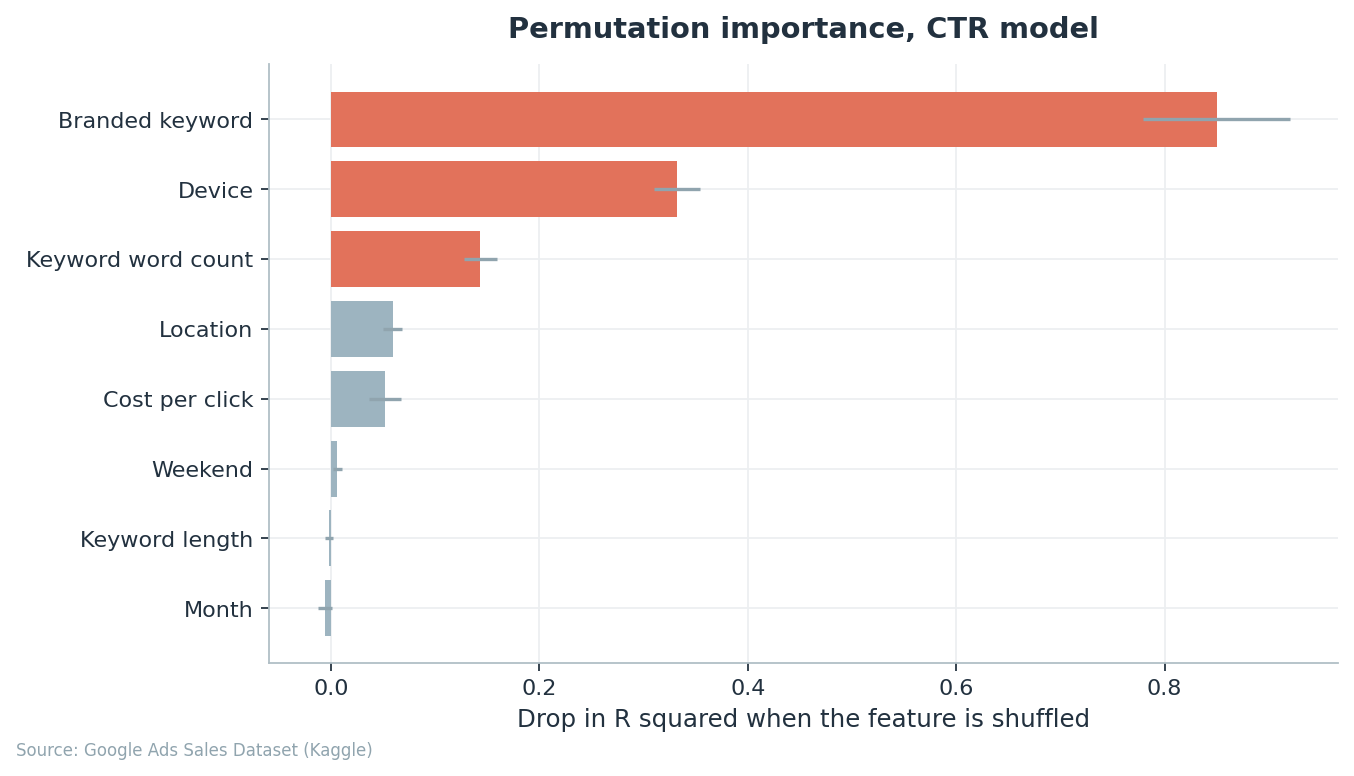

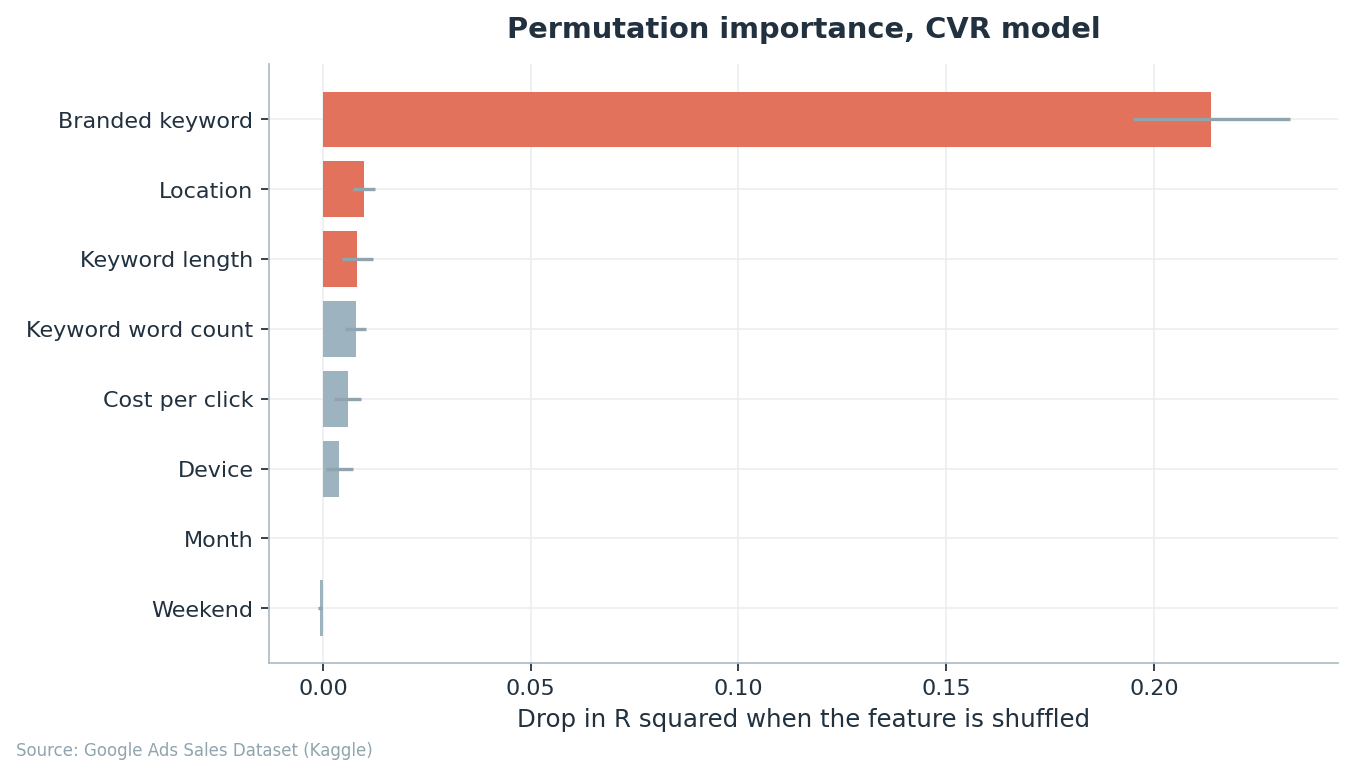

In [19]:
display(Image("reports/figures/11_importance_ctr.png"))
display(Image("reports/figures/13_importance_cvr.png"))

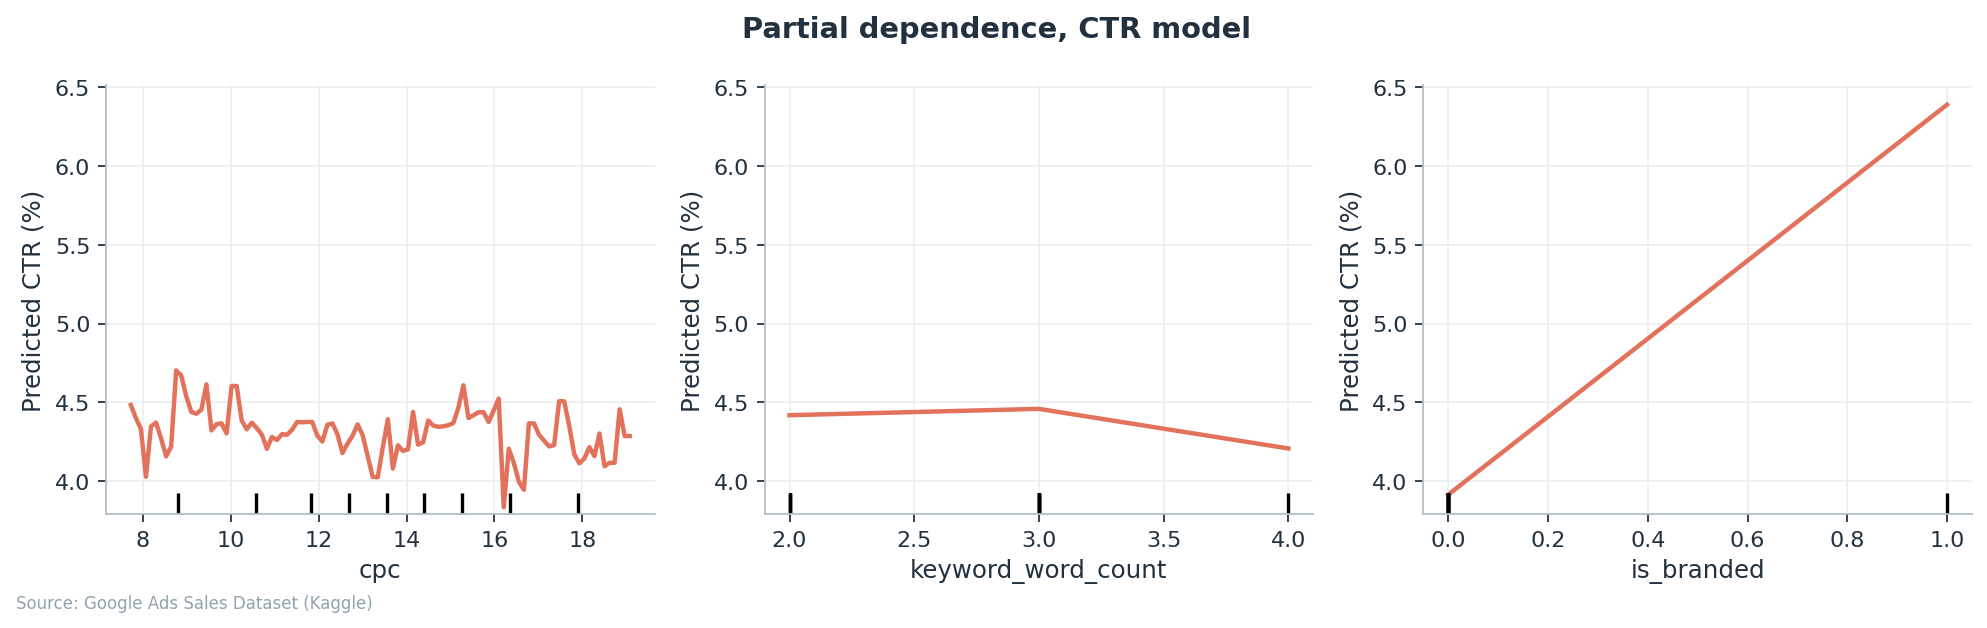

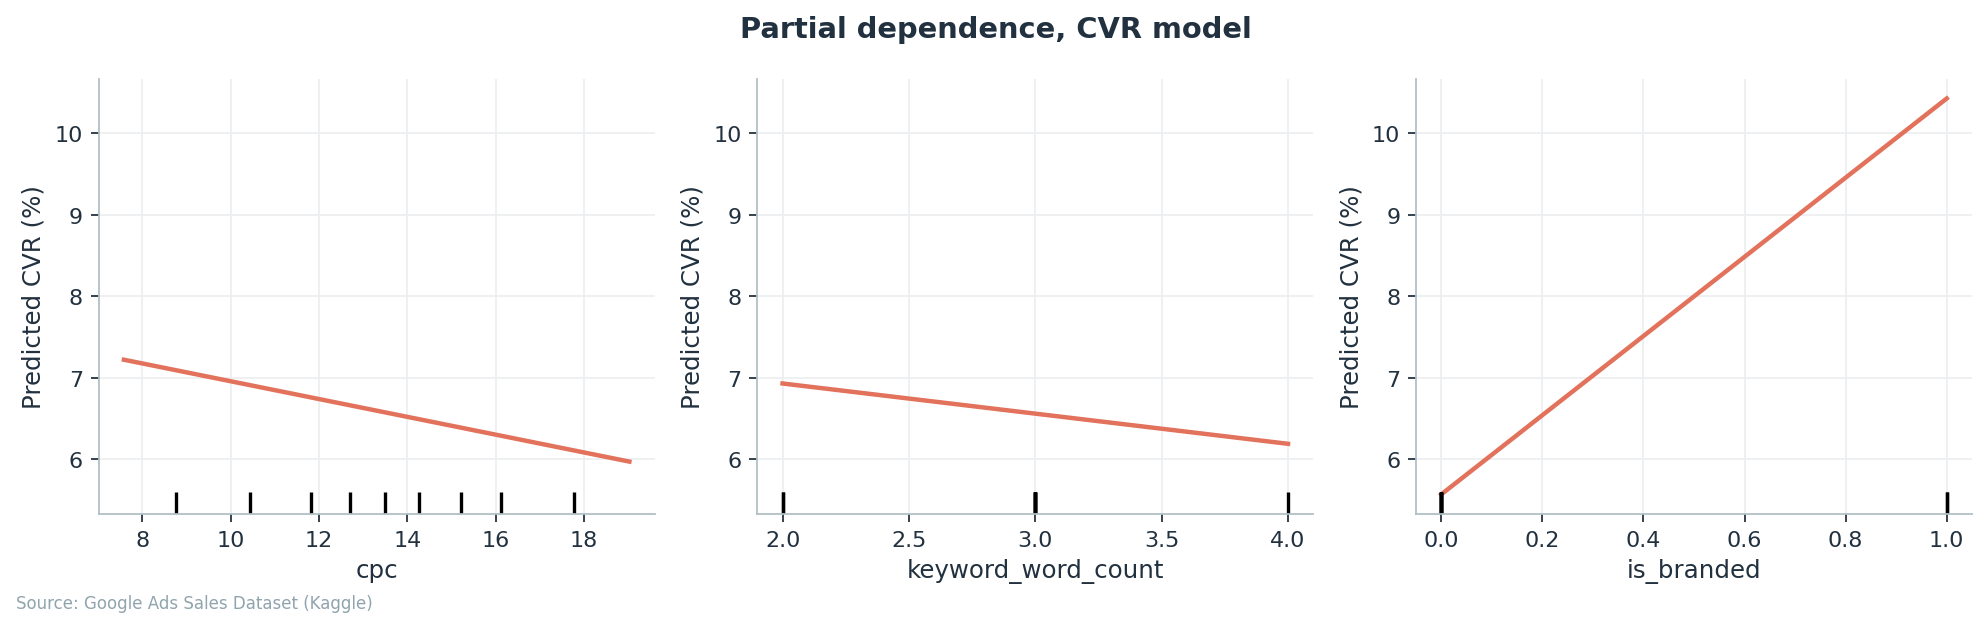

In [20]:
display(Image("reports/figures/12_pdp_ctr.png"))
display(Image("reports/figures/14_pdp_cvr.png"))

CTR is considerably more predictable than CVR from this feature set. That gap
is itself a finding: clicking happens inside the search results page, where
the variables we observe (device, query type, brand affinity) live. Converting
happens after the click, on a landing page we have no features for. With only
pre-click variables, a low CVR R squared is the honest result, not a modeling
failure.

The permutation rankings agree with the regression: the branded flag and
device dominate CTR, the branded flag dominates CVR, and location plays a
secondary role.

## Phase 5: findings and recommendations

**What moves CTR.** The branded keyword flag is the single largest driver,
followed by device, with mobile clearly ahead of desktop and tablet behind.
Location effects are real but smaller. Paying a higher CPC does not, by
itself, buy a better CTR.

**What moves CVR.** Branded intent again leads by a wide margin. Device flips
direction here: mobile clicks convert slightly worse than desktop clicks,
the classic browse-on-mobile, buy-on-desktop pattern. Longer, more specific
queries convert a little better.

**What a growth team should do with this.**

1. Report branded and non-branded performance separately. Blending them
   flatters every average and hides the true cost of growth.
2. Bid device aware: mobile earns clicks cheaply, desktop closes them.
   If the platform allows it, a positive mobile adjustment on awareness
   campaigns and a positive desktop adjustment on conversion campaigns
   follows directly from the coefficients.
3. Work the hidden gems quadrant first. Keywords that convert well but get
   few clicks need better ad copy or higher positions, which is cheaper than
   finding new keywords.
4. Audit the curiosity clicks quadrant for message match between ad and
   landing page before spending another month on them.
5. Treat CVR prediction with humility. Without landing page and audience
   features, models cannot see most of what decides a conversion. The next
   data to collect is post-click, not more of the same.

**Limitations.** The dataset is simulated, covers a single advertiser and one
year, and aggregates at the ad level rather than the auction level. Effects
here are associations under a linear model, not causal estimates. The value
of the project is the method: the same pipeline runs unchanged on a real
account export with these columns.